Worst Drawdown (Strategy): -38.37% on 2026-03-02
Worst Drawdown (NIFTY):    -38.39%

Top 5 Worst Drawdowns (Strategy):
Date
2026-03-02   -0.3837
2026-02-27   -0.3831
2026-02-26   -0.3831
2026-02-25   -0.3831
2026-02-24   -0.3831
Name: strategy_dd, dtype: float64

Average Recovery Days: 728.3
Max Recovery Days:     1482

Drawdown Duration Distribution (Top 5 Longest):
strategy_dd
18    1482
8       15
4        3
10       3
2        2
Name: recovery_days, dtype: int64


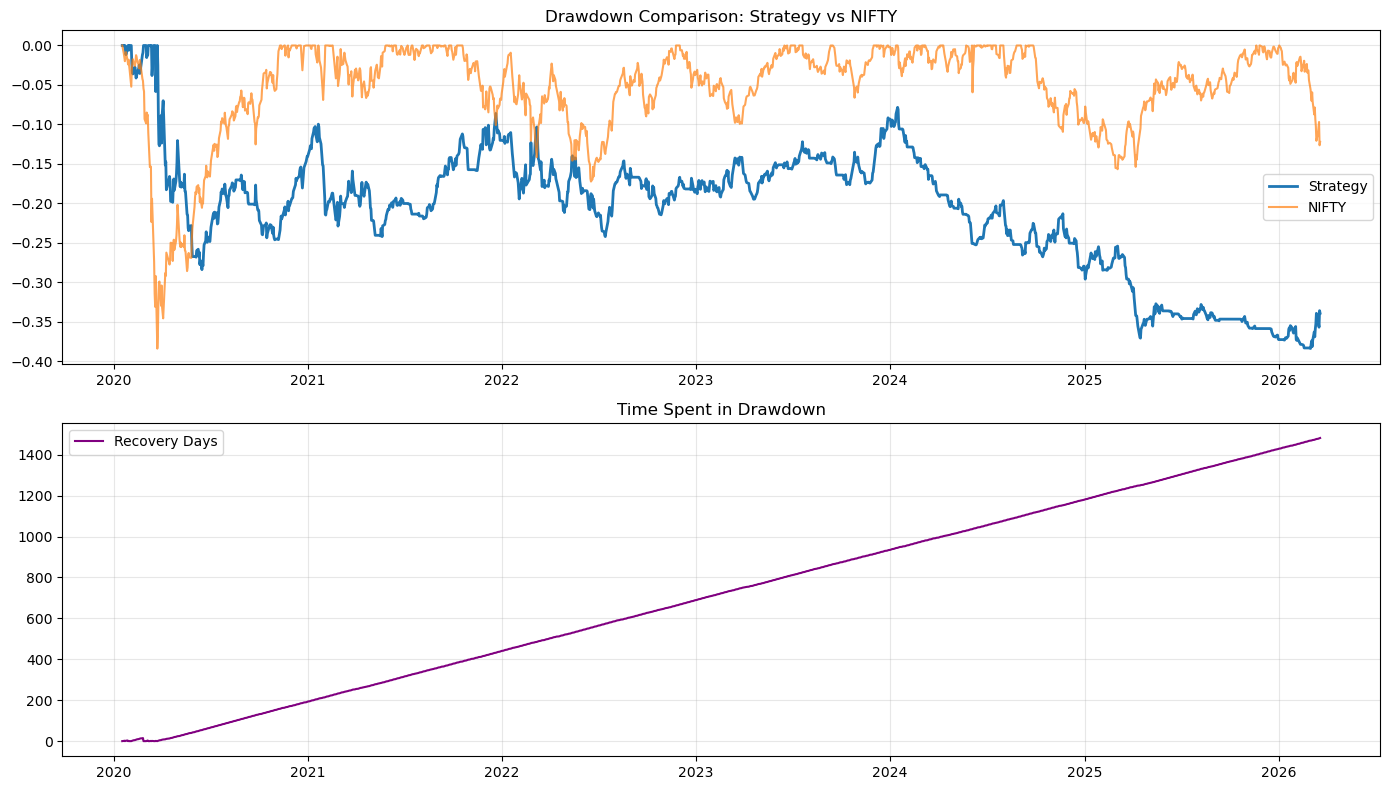

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =============================================
# 1. LOAD DATA
# =============================================
market = pd.read_csv("../backtesting/market_backtest_v6.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

# =============================================
# 2. DRAWDOWN CALCULATION
# =============================================
market["strategy_dd"] = (
    market["strategy_equity"] / market["strategy_equity"].cummax() - 1
)

market["benchmark_dd"] = (
    market["benchmark_equity"] / market["benchmark_equity"].cummax() - 1
)

# =============================================
# 3. KEY DRAWDOWN METRICS
# =============================================
worst_dd = market["strategy_dd"].min()
worst_date = market["strategy_dd"].idxmin()

benchmark_worst = market["benchmark_dd"].min()

print(f"Worst Drawdown (Strategy): {worst_dd:.2%} on {worst_date.date()}")
print(f"Worst Drawdown (NIFTY):    {benchmark_worst:.2%}")

print("\nTop 5 Worst Drawdowns (Strategy):")
print(market["strategy_dd"].nsmallest(5).round(4))

# =============================================
# 4. RECOVERY ANALYSIS (FIXED VERSION)
# =============================================
drawdown = market["strategy_dd"]

in_drawdown = drawdown < 0

# Identify drawdown regimes
drawdown_groups = (in_drawdown != in_drawdown.shift()).cumsum()

# Count consecutive drawdown days
market["recovery_days"] = in_drawdown.groupby(drawdown_groups).cumsum()

# Metrics
avg_recovery = market["recovery_days"][market["recovery_days"] > 0].mean()
max_recovery = market["recovery_days"].max()

print(f"\nAverage Recovery Days: {avg_recovery:.1f}")
print(f"Max Recovery Days:     {max_recovery}")

# =============================================
# 5. DRAWDOWN DURATION DISTRIBUTION
# =============================================
drawdown_durations = market.groupby(drawdown_groups)["recovery_days"].max()

print("\nDrawdown Duration Distribution (Top 5 Longest):")
print(drawdown_durations.sort_values(ascending=False).head())

# =============================================
# 6. VISUALIZATION
# =============================================
plt.figure(figsize=(14, 8))

# Drawdown Comparison
plt.subplot(2, 1, 1)
plt.plot(market.index, market["strategy_dd"], label="Strategy", linewidth=2)
plt.plot(market.index, market["benchmark_dd"], label="NIFTY", alpha=0.7)
plt.title("Drawdown Comparison: Strategy vs NIFTY")
plt.legend()
plt.grid(True, alpha=0.3)

# Recovery Days
plt.subplot(2, 1, 2)
plt.plot(market.index, market["recovery_days"], label="Recovery Days", color='purple')
plt.title("Time Spent in Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# 7. SAVE
market.to_csv("../backtesting/market_backtest_v7.csv")